# Домашнее задание 1

## AG News: один сильный transformer до macro F1 0.95


## 1. Установка зависимостей


In [1]:
import importlib.util
import subprocess
import sys

PACKAGE_PLAN = {
    "transformers": "transformers>=4.42",
}

missing_packages = [
    install_name
    for module_name, install_name in PACKAGE_PLAN.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print("Ставлю недостающие пакеты:", ", ".join(missing_packages))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", *missing_packages])
else:
    print("Все внешние зависимости уже на месте.")

Ставлю недостающие пакеты: transformers>=4.42


## 2. Импорты и единая панель настроек

In [2]:
from pathlib import Path
import math
import random
import urllib.request

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup

SEED = 42
DATA_DIR = Path("data")
CHECKPOINT_DIR = Path("checkpoints/ag_news_single_transformer_target_095")

MODEL_NAME = "FacebookAI/roberta-base"
TARGET_MACRO_F1 = 0.95
MAX_EPOCHS = 5
PATIENCE_AFTER_TARGET_MISS = 2

MAX_TOKENS = 128
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
GRADIENT_ACCUMULATION = 2
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.08
NUM_WORKERS = 0

LABEL_NAMES = ["World", "Sports", "Business", "Sci/Tech"]
LABEL_TO_ID = {name: idx for idx, name in enumerate(LABEL_NAMES)}
ID_TO_LABEL = {idx: name for idx, name in enumerate(LABEL_NAMES)}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = device.type == "cuda"
PIN_MEMORY = device.type == "cuda"

print(f"Устройство: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Модель: {MODEL_NAME}")
print(f"Целевой macro F1: {TARGET_MACRO_F1:.2f}")

Устройство: cuda
GPU: NVIDIA GeForce RTX 3080 Ti
Модель: FacebookAI/roberta-base
Целевой macro F1: 0.95


## 3. Данные AG News



In [3]:
def fetch_ag_news_csv(data_dir: Path) -> dict[str, Path]:
    data_dir.mkdir(parents=True, exist_ok=True)
    urls = {
        "train": "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv",
        "test": "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv",
    }

    paths = {}
    for split_name, url in urls.items():
        csv_path = data_dir / f"{split_name}.csv"
        if not csv_path.exists():
            print(f"Загружаю {split_name}: {csv_path}")
            urllib.request.urlretrieve(url, csv_path)
        paths[split_name] = csv_path
    return paths


def read_ag_news(csv_path: Path) -> pd.DataFrame:
    frame = pd.read_csv(csv_path, header=None, names=["raw_label", "title", "description"])
    frame["text"] = (frame["title"].fillna("") + " " + frame["description"].fillna("")).str.strip()
    frame["label"] = frame["raw_label"].astype(int) - 1
    return frame[["text", "label"]]


csv_paths = fetch_ag_news_csv(DATA_DIR)
train_full = read_ag_news(csv_paths["train"])
test_frame = read_ag_news(csv_paths["test"])

train_frame, valid_frame = train_test_split(
    train_full,
    test_size=0.10,
    stratify=train_full["label"],
    random_state=SEED,
)

print(f"Train: {len(train_frame):,}")
print(f"Valid: {len(valid_frame):,}")
print(f"Test:  {len(test_frame):,}")
display(train_frame.sample(5, random_state=SEED).assign(section=lambda df: df["label"].map(ID_TO_LABEL)))

Train: 108,000
Valid: 12,000
Test:  7,600


,text,label,section
53973,"Eugene Melnyk stepping down as Biovail CEO, wi...",2,Business
59731,Great Lakes to Get Asian Carp Barrier (AP) AP ...,3,Sci/Tech
110557,Snow to Remain as U.S. Treasury Secretary WAS...,2,Business
117146,Counsell Returns to the Diamondbacks (Reuters)...,1,Sports
111904,Ciena's Loss Tempered By Rise in Revenue Ciena...,3,Sci/Tech


## 4. Быстрый взгляд на баланс классов

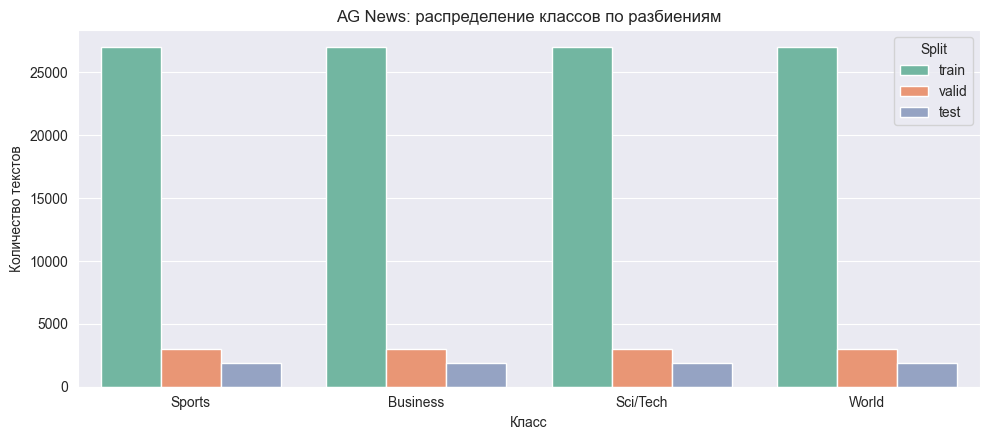

In [4]:
balance_frame = pd.concat([
    train_frame.assign(split="train"),
    valid_frame.assign(split="valid"),
    test_frame.assign(split="test"),
])
balance_frame["section"] = balance_frame["label"].map(ID_TO_LABEL)

plt.figure(figsize=(10, 4.5))
sns.countplot(data=balance_frame, x="section", hue="split", palette="Set2")
plt.title("AG News: распределение классов по разбиениям")
plt.xlabel("Класс")
plt.ylabel("Количество текстов")
plt.legend(title="Split")
plt.tight_layout()
plt.show()

## 5. Токенизация и DataLoader


In [5]:
def tokenize_in_blocks(
    texts: list[str],
    tokenizer: AutoTokenizer,
    max_tokens: int,
    block_size: int = 2_048,
) -> dict[str, list[list[int]]]:
    storage: dict[str, list[list[int]]] = {}
    for start in tqdm(range(0, len(texts), block_size), desc="Токенизация", leave=False):
        block = texts[start:start + block_size]
        encoded = tokenizer(
            block,
            truncation=True,
            padding="max_length",
            max_length=max_tokens,
        )
        for key, values in encoded.items():
            storage.setdefault(key, []).extend(values)
    return storage


class NewsDigestDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, tokenizer: AutoTokenizer, max_tokens: int):
        self.labels = frame["label"].astype(int).to_list()
        self.encoded = tokenize_in_blocks(frame["text"].to_list(), tokenizer, max_tokens)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, index: int) -> dict[str, torch.Tensor]:
        item = {
            key: torch.tensor(values[index], dtype=torch.long)
            for key, values in self.encoded.items()
        }
        item["labels"] = torch.tensor(self.labels[index], dtype=torch.long)
        return item


def make_loader(dataset: Dataset, batch_size: int, shuffle: bool) -> DataLoader:
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )


news_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

train_digest = NewsDigestDataset(train_frame, news_tokenizer, MAX_TOKENS)
valid_digest = NewsDigestDataset(valid_frame, news_tokenizer, MAX_TOKENS)
test_digest = NewsDigestDataset(test_frame, news_tokenizer, MAX_TOKENS)

train_stream = make_loader(train_digest, TRAIN_BATCH_SIZE, shuffle=True)
valid_stream = make_loader(valid_digest, EVAL_BATCH_SIZE, shuffle=False)
test_stream = make_loader(test_digest, EVAL_BATCH_SIZE, shuffle=False)

first_batch = next(iter(train_stream))
print("Первый батч готов:", {key: tuple(value.shape) for key, value in first_batch.items()})

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

C:\Users\ART PRONKIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ART PRONKIN\.cache\huggingface\hub\models--FacebookAI--roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Токенизация:   0%|          | 0/53 [00:00<?, ?it/s]

Токенизация:   0%|          | 0/6 [00:00<?, ?it/s]

Токенизация:   0%|          | 0/4 [00:00<?, ?it/s]

Первый батч готов: {'input_ids': (16, 128), 'attention_mask': (16, 128), 'labels': (16,)}


## 6. Модель

Одна модель, без ансамблей: transformer encoder + классификационная голова на 4 класса.

In [6]:
newsroom_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL_NAMES),
    id2label=ID_TO_LABEL,
    label2id=LABEL_TO_ID,
).to(device)

trainable_params = sum(param.numel() for param in newsroom_model.parameters() if param.requires_grad)
print(f"Обучаемых параметров: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Обучаемых параметров: 124,648,708


## 7. Метрики, оптимизатор и служебные функции

In [7]:
updates_per_epoch = math.ceil(len(train_stream) / GRADIENT_ACCUMULATION)
total_training_steps = updates_per_epoch * MAX_EPOCHS
warmup_steps = int(total_training_steps * WARMUP_RATIO)

optimizer = torch.optim.AdamW(
    newsroom_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps,
)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


def send_to_device(batch: dict[str, torch.Tensor]) -> dict[str, torch.Tensor]:
    return {key: value.to(device, non_blocking=PIN_MEMORY) for key, value in batch.items()}


def collect_metrics(model, loader: DataLoader, caption: str) -> dict[str, object]:
    model.eval()
    losses, predictions, gold = [], [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc=caption, leave=False):
            batch = send_to_device(batch)
            outputs = model(**batch)
            losses.append(outputs.loss.item())
            batch_predictions = outputs.logits.argmax(dim=-1).detach().cpu().numpy()
            predictions.extend(batch_predictions.tolist())
            gold.extend(batch["labels"].detach().cpu().numpy().tolist())

    return {
        "loss": float(np.mean(losses)),
        "accuracy": accuracy_score(gold, predictions),
        "macro_f1": f1_score(gold, predictions, average="macro"),
        "labels": gold,
        "predictions": predictions,
    }


def train_one_round(model, loader: DataLoader, epoch_index: int) -> dict[str, float]:
    model.train()
    optimizer.zero_grad(set_to_none=True)
    losses, predictions, gold = [], [], []

    progress = tqdm(loader, desc=f"Раунд {epoch_index:02d}: обучение", leave=False)
    for step, batch in enumerate(progress, start=1):
        batch = send_to_device(batch)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            outputs = model(**batch)
            loss = outputs.loss / GRADIENT_ACCUMULATION

        scaler.scale(loss).backward()

        if step % GRADIENT_ACCUMULATION == 0 or step == len(loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)

        real_loss = loss.item() * GRADIENT_ACCUMULATION
        losses.append(real_loss)
        batch_predictions = outputs.logits.argmax(dim=-1).detach().cpu().numpy()
        predictions.extend(batch_predictions.tolist())
        gold.extend(batch["labels"].detach().cpu().numpy().tolist())
        progress.set_postfix(loss=f"{np.mean(losses):.4f}")

    return {
        "loss": float(np.mean(losses)),
        "accuracy": accuracy_score(gold, predictions),
        "macro_f1": f1_score(gold, predictions, average="macro"),
    }


def save_champion(model, tokenizer, checkpoint_dir: Path) -> None:
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(checkpoint_dir)
    tokenizer.save_pretrained(checkpoint_dir)

C:\Users\ART PRONKIN\AppData\Local\Temp\ipykernel_19336\324719943.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


## 8. Обучение с остановкой по 0.95

Главное условие остановки: как только validation macro F1 достигает **0.95**, модель сохраняется и обучение завершается. Patience оставлен как запасной предохранитель, если качество перестало расти.

In [8]:
history_rows = []
best_validation_f1 = -1.0
stale_rounds = 0
target_reached = False

for epoch in range(1, MAX_EPOCHS + 1):
    train_stats = train_one_round(newsroom_model, train_stream, epoch)
    valid_stats = collect_metrics(newsroom_model, valid_stream, caption=f"Раунд {epoch:02d}: validation")

    row = {
        "epoch": epoch,
        "train_loss": train_stats["loss"],
        "train_accuracy": train_stats["accuracy"],
        "train_macro_f1": train_stats["macro_f1"],
        "valid_loss": valid_stats["loss"],
        "valid_accuracy": valid_stats["accuracy"],
        "valid_macro_f1": valid_stats["macro_f1"],
        "learning_rate": scheduler.get_last_lr()[0],
    }
    history_rows.append(row)

    print(
        f"Раунд {epoch:02d} | "
        f"train loss {row['train_loss']:.4f}, train F1 {row['train_macro_f1']:.4f} | "
        f"valid loss {row['valid_loss']:.4f}, valid F1 {row['valid_macro_f1']:.4f}, "
        f"valid acc {row['valid_accuracy']:.4f}"
    )

    if row["valid_macro_f1"] > best_validation_f1:
        best_validation_f1 = row["valid_macro_f1"]
        stale_rounds = 0
        save_champion(newsroom_model, news_tokenizer, CHECKPOINT_DIR)
        print(f"Сохранен новый чемпион: validation macro F1 = {best_validation_f1:.4f}")
    else:
        stale_rounds += 1
        print(f"Без улучшения: {stale_rounds}/{PATIENCE_AFTER_TARGET_MISS}")

    if row["valid_macro_f1"] >= TARGET_MACRO_F1:
        target_reached = True
        print(f"Порог ТЗ взят на validation: {row['valid_macro_f1']:.4f} >= {TARGET_MACRO_F1:.2f}. Останавливаемся.")
        break

    if stale_rounds >= PATIENCE_AFTER_TARGET_MISS:
        print("Качество перестало расти, сработала ранняя остановка.")
        break

history = pd.DataFrame(history_rows)
print(f"Лучший validation macro F1: {best_validation_f1:.4f}")
if not target_reached:
    print("Порог 0.95 на validation пока не взят. Для финального прогона увеличьте MAX_EPOCHS или замените MODEL_NAME на более крупный transformer.")

display(history)

Раунд 01: обучение:   0%|          | 0/6750 [00:00<?, ?it/s]

C:\Users\ART PRONKIN\AppData\Local\Temp\ipykernel_19336\324719943.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Раунд 01: validation:   0%|          | 0/375 [00:00<?, ?it/s]

Раунд 01 | train loss 0.2996, train F1 0.8912 | valid loss 0.1892, valid F1 0.9379, valid acc 0.9380


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Раунд 03: validation:   0%|          | 0/375 [00:00<?, ?it/s]

Раунд 03 | train loss 0.1138, train F1 0.9636 | valid loss 0.1651, valid F1 0.9508, valid acc 0.9507


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Сохранен новый чемпион: validation macro F1 = 0.9508
Порог ТЗ взят на validation: 0.9508 >= 0.95. Останавливаемся.
Лучший validation macro F1: 0.9508


,epoch,train_loss,train_accuracy,train_macro_f1,valid_loss,valid_accuracy,valid_macro_f1,learning_rate
0,1,0.299556,0.891278,0.891176,0.189167,0.93800,0.937893,0.000017
1,2,0.153551,0.949435,0.949460,0.165886,0.94675,0.946866,0.000013
2,3,0.113765,0.963556,0.963582,0.165131,0.95075,0.950767,0.000009


## 9. Визуализация обучения

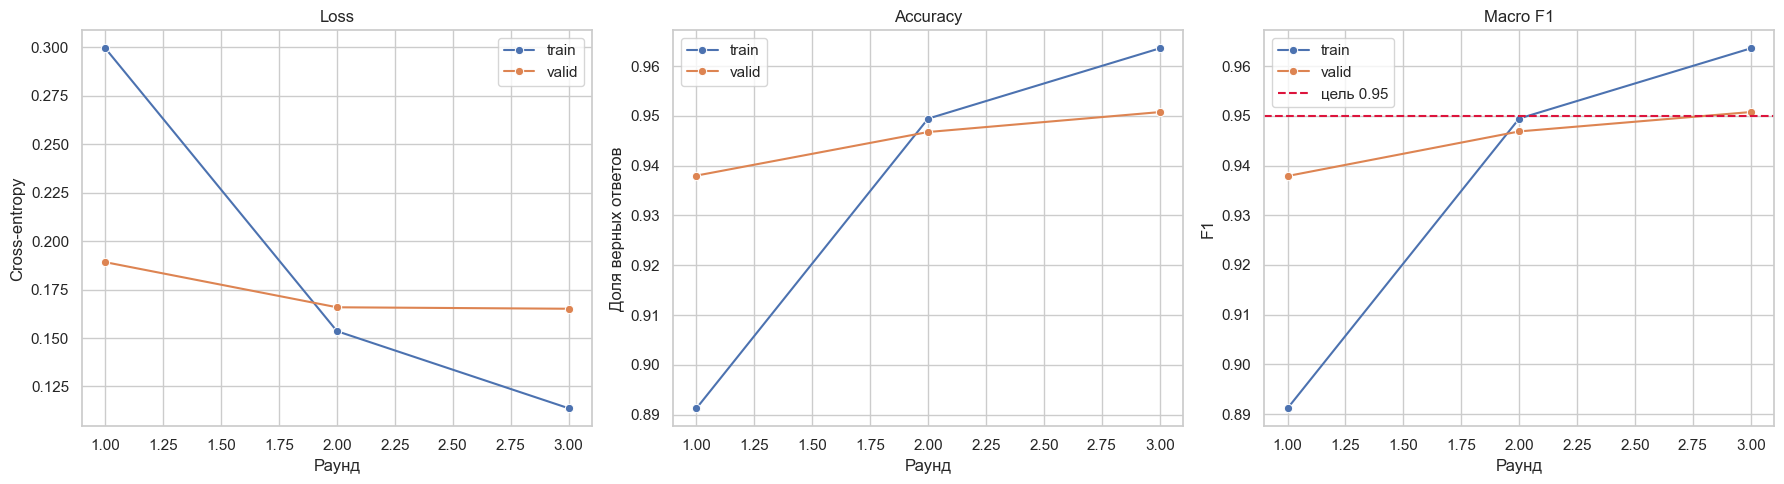

In [9]:
sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(data=history, x="epoch", y="train_loss", marker="o", label="train", ax=axes[0])
sns.lineplot(data=history, x="epoch", y="valid_loss", marker="o", label="valid", ax=axes[0])
axes[0].set_title("Loss")
axes[0].set_xlabel("Раунд")
axes[0].set_ylabel("Cross-entropy")

sns.lineplot(data=history, x="epoch", y="train_accuracy", marker="o", label="train", ax=axes[1])
sns.lineplot(data=history, x="epoch", y="valid_accuracy", marker="o", label="valid", ax=axes[1])
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Раунд")
axes[1].set_ylabel("Доля верных ответов")

sns.lineplot(data=history, x="epoch", y="train_macro_f1", marker="o", label="train", ax=axes[2])
sns.lineplot(data=history, x="epoch", y="valid_macro_f1", marker="o", label="valid", ax=axes[2])
axes[2].axhline(TARGET_MACRO_F1, color="crimson", linestyle="--", label="цель 0.95")
axes[2].set_title("Macro F1")
axes[2].set_xlabel("Раунд")
axes[2].set_ylabel("F1")
axes[2].legend()

plt.tight_layout()
plt.show()

## 10. Финальная проверка на test

In [10]:
champion_model = AutoModelForSequenceClassification.from_pretrained(CHECKPOINT_DIR).to(device)
test_stats = collect_metrics(champion_model, test_stream, caption="Финальный test")

print(f"Test loss:     {test_stats['loss']:.4f}")
print(f"Test accuracy: {test_stats['accuracy']:.4f}")
print(f"Test macro F1: {test_stats['macro_f1']:.4f}")
print()
print(classification_report(
    test_stats["labels"],
    test_stats["predictions"],
    target_names=LABEL_NAMES,
    digits=4,
))

assert test_stats["macro_f1"] >= TARGET_MACRO_F1, (
    f"Нужно >= {TARGET_MACRO_F1:.2f} macro F1 на test, "
    f"сейчас {test_stats['macro_f1']:.4f}. Увеличьте MAX_EPOCHS или возьмите MODEL_NAME='FacebookAI/roberta-large'."
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Финальный test:   0%|          | 0/238 [00:00<?, ?it/s]

Test loss:     0.1687
Test accuracy: 0.9503
Test macro F1: 0.9503

              precision    recall  f1-score   support

       World     0.9581    0.9626    0.9604      1900
      Sports     0.9915    0.9879    0.9897      1900
    Business     0.9319    0.9147    0.9232      1900
    Sci/Tech     0.9198    0.9358    0.9277      1900

    accuracy                         0.9503      7600
   macro avg     0.9503    0.9503    0.9503      7600
weighted avg     0.9503    0.9503    0.9503      7600



## 11. Confusion matrix

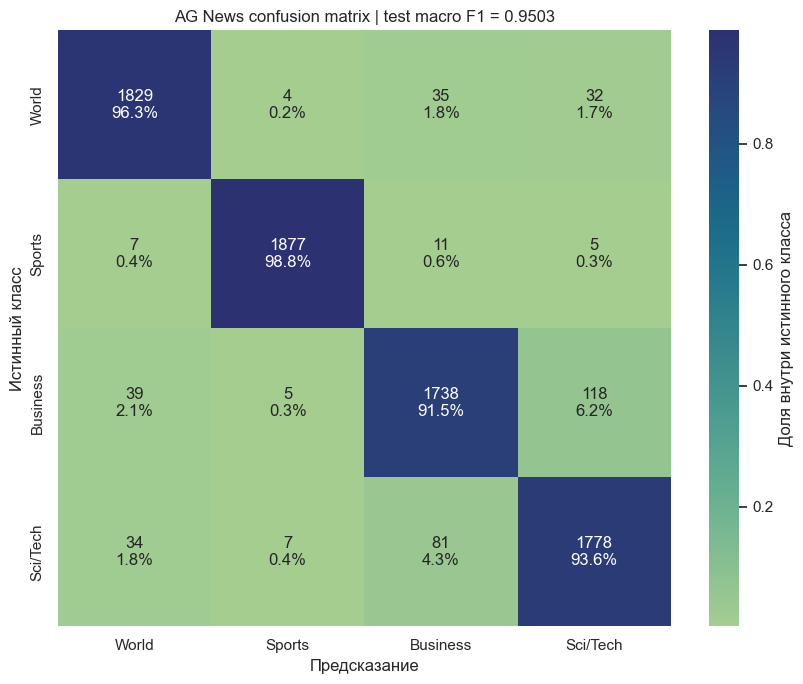

In [11]:
matrix = confusion_matrix(test_stats["labels"], test_stats["predictions"])
matrix_percent = matrix / matrix.sum(axis=1, keepdims=True)
annotations = np.empty_like(matrix).astype(str)
for row in range(matrix.shape[0]):
    for col in range(matrix.shape[1]):
        annotations[row, col] = f"{matrix[row, col]}\n{matrix_percent[row, col]:.1%}"

plt.figure(figsize=(8.5, 7))
sns.heatmap(
    matrix_percent,
    annot=annotations,
    fmt="",
    cmap="crest",
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
    cbar_kws={"label": "Доля внутри истинного класса"},
)
plt.title(f"AG News confusion matrix | test macro F1 = {test_stats['macro_f1']:.4f}")
plt.xlabel("Предсказание")
plt.ylabel("Истинный класс")
plt.tight_layout()
plt.show()